# Synthetic Experiments using Realistic Schedules

Not adversarial schedules. Following the FKC paper, we sample 10k samples with 1000 sampling steps.

In [1]:
%reload_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized
from hcg.interpolant import Interpolant as Interpolant
from hcg.interpolant import FlowMatcher as FlowMatcher
from hcg.interpolant import plot_path_trajectories as plot_path_trajectories
import json
from IPython.display import clear_output
import itertools
import json

Device: cuda


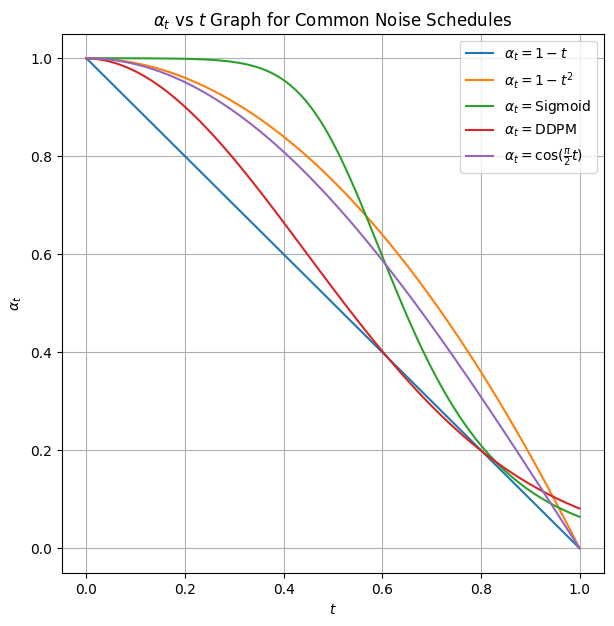

There are 80 combinations that have path collapse:


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("Device:", device)

top_experiment_id = "[251118] Frequency of Collapse"  # Use a fixed ID for reproducibility
if not os.path.exists(top_experiment_id):
    os.makedirs(top_experiment_id)

model_path = "PretrainedToyModels"

experiment_id = f"{top_experiment_id}/common_schedules"
if os.path.exists(experiment_id) is False:
    os.makedirs(experiment_id)

def load_interpolants_from_json_alpha_only(path):
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        interpolants[name] = alpha_t
    return interpolants

# Load
interpolants = load_interpolants_from_json_alpha_only("interpolant_schedules.json")
names = list(interpolants.keys())

t = torch.linspace(0.0, 1.0, 100)

name_eq = {
    "ddpm_linear": r"$\alpha_t = \text{DDPM}$",
    "1-t**2": r"$\alpha_t = 1-t^2$",
    "sigmoid": r"$\alpha_t = \text{Sigmoid}$",
    "default_linear": r"$\alpha_t = 1-t$",
    "cos_t": r"$\alpha_t=\cos(\frac{\pi}{2}t)$"
}

plt.figure(figsize=(7, 7)) 
for name in interpolants.keys():
    plt.plot(t.numpy(), interpolants[name](t).numpy(), label=name_eq[name])
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha_t$')
plt.title(r'$\alpha_t$ vs $t$ Graph for Common Noise Schedules')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "alpha_t_plot_common_schedules.png"))
plt.show()
plt.close()

def check_condition(alpha_funcs, n_grid=200, Bump = 0.0, Anneal_weight=1.0):
    """Check sign conditions for [a1, a2, a3]. a1 a3 / a2 and anneal weight applies to (a1 / a2)^w a3"""
    ts = torch.linspace(0.0, 0.99, n_grid)

    if n_grid > 1:
        dt = ts[1] - ts[0]
    else:
        dt = torch.tensor(0.0) 

    alphas = [f(ts) for f in alpha_funcs]
    Bumps = torch.tensor([Bump * t * (1-t) for t in ts])
    if len(alpha_funcs) == 3:
        C = (Anneal_weight + Bumps) / (alphas[0]**2 + 1e-12) - Anneal_weight / (alphas[1]**2 + 1e-12) + 1 / (alphas[2]**2 + 1e-12)
    else:
        raise ValueError("Only supports 3 schedules")

    total_negative_length = 0.0
    if n_grid > 1:
        negative_intervals = C[:-1] < 0
        total_negative_length_tensor = torch.sum(negative_intervals.float()) * dt
        total_negative_length = total_negative_length_tensor.item()

    return (C.min() < 0), ts, C, total_negative_length # or depth?

name_eq_plot = {
    "ddpm_linear": r"$\text{DDPM}$",
    "1-t**2": r"$1-t^2$",
    "sigmoid": r"$\text{Sigmoid}$",
    "default_linear": r"$1-t$",
    "cos_t": r"$\cos(\frac{\pi}{2}t)$"
}


def find_valid_combinations(interpolants, Anneal_weight=1.0, Bump=0.0, unique=True):
    collapse_combinations = []

    for a1, a2, a3 in itertools.product(interpolants, repeat=3):
        valid, t, C, total_negative_length = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], Anneal_weight=Anneal_weight, Bump=Bump)
        if valid:
            collapse_combinations.append([a1, a2, a3, total_negative_length])
    collapse_combinations.sort(key=lambda x: x[3], reverse=True)
    if unique:
        unique_combinations = []
        seen = set()
        for combo in collapse_combinations:
            identifier = combo[3]
            if identifier not in seen:
                unique_combinations.append(combo)
                seen.add(identifier)
        collapse_combinations = unique_combinations # Remove duplicates if total_negative_length is the same
    return collapse_combinations

collapse_combinations = find_valid_combinations(interpolants, Anneal_weight=1000, Bump=0.0, unique=False)
print(f"There are {len(collapse_combinations)} combinations that have path collapse:")

with open(os.path.join(experiment_id, "non_unique_collapse_combinations.json"), "w") as f:
    json.dump(collapse_combinations, f, indent=4)

# for Bump in [0.0, 20, 30]:
#     plt.figure(figsize=(9,7))
#     plt.title(f'Criterion C(t) with Bump={Bump} for Invalid Common Cases')
#     for names in collapse_combinations:
#         a1, a2, a3, invalid_interval = names
#         valid, t, C, invalid_interval = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], Anneal_weight=1.0, Bump=Bump)
#         plt.ylim((-20,100))
#         plt.grid(True)
#         plt.plot(t.numpy(), C.numpy(), label=f'{name_eq_plot[a1]}, {name_eq_plot[a2]}, {name_eq_plot[a3]}')
#         plt.legend(loc='lower left', fontsize='small')
#     plt.xlabel('t')
#     plt.ylabel(r"$C(t)$")
#     plt.savefig(os.path.join(experiment_id, f"Criterion_plot_a1a2a3_bump={Bump}.png"))
#     plt.show()
#     plt.close()

In [ ]:
for names in collapse_combinations:
    bs = 10000; n_steps=100
    seeds = [0] #[0,1,2,3,4]
    ESS_THRESHOLD = 0.7
    ANNEAL_WEIGHT = 1.0
    BUMP_VALUE = 30.0
    RUN_METRIC_EVAL = False
    results = []

    subexperiment_id = f"{names}"
    experiment_id = f"{top_experiment_id}/[{names[3]:.4f}]{subexperiment_id}_Visualizations"
    if not os.path.exists(experiment_id):
        os.makedirs(experiment_id)

    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

    def v1_fn(x, t, A): return u_model1(x, t, A)
    def s1_fn(x, t, A): return s_model1(x, t, A)
    def v2_fn(x, t): return u_model3(x, t)
    def s2_fn(x, t): return s_model3(x, t)
    def v3_fn(z, t, B): return u_model2(z, t, B)
    def s3_fn(z, t, B): return s_model2(z, t, B)
    def sigma_fn(t): return 0.5 * torch.ones_like(t)

    v_fn_list=[
            lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
            lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
            lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
        ]
    s_fn_list=[
            lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
            lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
            lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
        ]
    proj_list=[
            lambda z: z[:, :1],    # project to X 
            lambda z: z[:, :1],    # project to X
            lambda z: z            # identity for Z
        ]
    emb_list=[
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda z: z  # identity
        ]
    print(f"{names} models loaded.")


    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f"Seed set to {seed}")

        for Method_name in ["NR", "FKC", "ACE"]:
            print(f"Method: {Method_name}")
            if Method_name == "FKC" or Method_name == "NR":
                    print("Simulating FKC (Constant Gammas)")
                    gamma_list = [
                        lambda t : torch.tensor(1) * ANNEAL_WEIGHT,
                        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
                        lambda t : torch.tensor(1)
                    ]
                    d_gamma_list = [
                        lambda t: torch.zeros_like(t),
                        lambda t: torch.zeros_like(t),
                        lambda t: torch.zeros_like(t)
                    ]
            elif Method_name == "ACE":
                print("Simulating ACE (Adaptive Gammas)")
                gamma_list = [
                    lambda t : torch.tensor(1) * ANNEAL_WEIGHT + (BUMP_VALUE * t * (1 - t)),
                    lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
                    lambda t : torch.tensor(1)
                ]
                d_gamma_list = [
                    lambda t: torch.zeros_like(t) + (BUMP_VALUE * (1 - 2*t)),
                    lambda t: torch.zeros_like(t),
                    lambda t: torch.zeros_like(t)
                ]
            if seed == 0:
                Criterion = lambda t: sum([ gamma_list[i](t) / (interpolants[names[i]](t))**2 for i in range(len(names)-1) ])
                t = torch.linspace(0.0, 0.99, 100)
                plt.plot(t.numpy(), Criterion(t).numpy())
                plt.xlabel('t')
                plt.ylabel('Criterion C(t)')
                plt.title('Criterion C(t) vs t')
                plt.grid(True)
                plt.ylim(-20,100)
                plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_Method={Method_name}.png"))
                plt.show()
                plt.close()

            # print when Criterion = 0
            for i in range(len(t)-1):
                if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
                    print("Criterion = 0 at t =", t[i].item())
                    break
            for i in range(len(t)-1):
                if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
                    print("Criterion = 0 at t =", t[i].item())
                    break
            for A, B in [(1,1), (1,0), (0,1), (0,0)]:
                print(f"Conditioning on A={A}, B={B}")

                x0 = torch.randn(bs, 2).to("cuda")
                samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
                    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
                    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
                    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=ESS_THRESHOLD, print_resample_history=True,
                    gamma_list=gamma_list,
                    d_gamma_list=d_gamma_list,
                    resample= (Method_name != "NR")
                )
                samples = samples.cpu().numpy()
                if seed == 0:
                    plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_{Method_name}_seed{seed}_AB={A}{B}_Bump={BUMP_VALUE}")
                    plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_{Method_name}_seed{seed}_AB={A}{B}_Bump={BUMP_VALUE}", deg=-50)
                    plt.close(); clear_output()

                if RUN_METRIC_EVAL:
                    print(f"Evaluating {Method_name} for AB={A}{B}")
                    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
                    w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                        torch.tensor(samples_gt), torch.tensor(samples)
                    )
                    results.append([seed, Method_name, w1, w2, mmd_rbf, total_var, A, B])

                    df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var.", "A", "B"])
                    df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_ESS{ESS_THRESHOLD}_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}.csv", index=False)

In [5]:
bs = 10000; n_steps=100
seeds = [0] #[0,1,2,3,4]
ESS_THRESHOLD = 0.7
ANNEAL_WEIGHT = 1.0
BUMP_VALUE = 30.0
RUN_METRIC_EVAL = False
results = []

for A, B in [(1,1), (1,0), (0,1), (0,0)]:
    print(f"Plot Ground Truth Conditioning on A={A}, B={B}")
    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
    plot_diagnostics(samples_gt, [], [], save_name=f"GT_AB={A}{B}_Bump={BUMP_VALUE}", full=False)
    plt.close(); clear_output()

Generating Plots...
Success! Plot saved to: [251117] Rebuttal Figures/Rebuttal_Facet_Grid_Summary.png


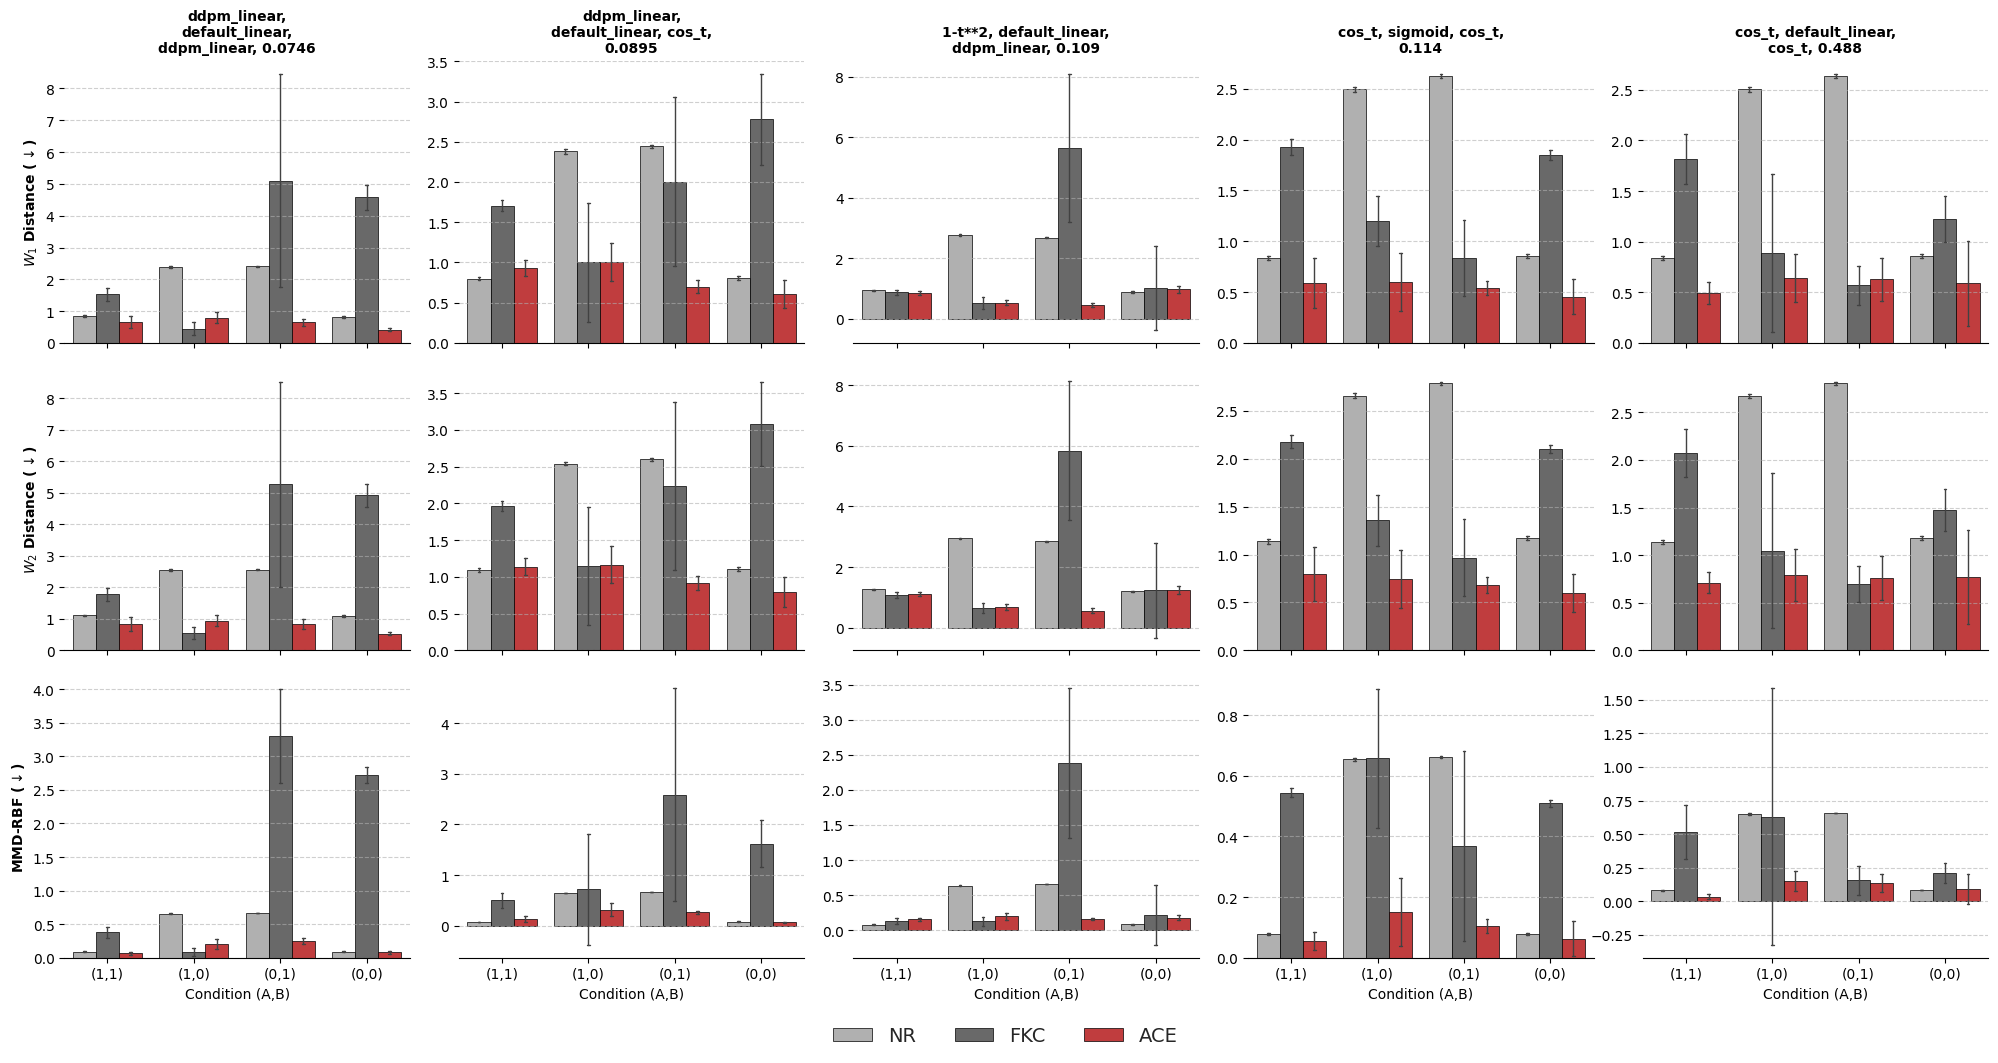

In [8]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
PARENT_DIR = "[251117] Rebuttal Figures"
OUTPUT_FILENAME = "Rebuttal_Facet_Grid_Summary.png"

# Metrics to plot (Rows)
METRICS = ['W1', 'W2', 'MMD_RBF']
METRIC_LABELS = {
    'W1': r'$W_1$ Distance ($\downarrow$)',
    'W2': r'$W_2$ Distance ($\downarrow$)',
    'MMD_RBF': r'MMD-RBF ($\downarrow$)'
}

# Methods and Colors (Highlight ACE)
PALETTE = {
    'NR': '#B0B0B0',   # Light Gray
    'FKC': '#696969',  # Dark Gray
    'ACE': '#D62728'   # Bold Red
}

# Order of plotting on X-axis
METHOD_ORDER = ['NR', 'FKC', 'ACE']

# ==========================================
# 1. DATA LOADING
# ==========================================
def load_all_data(parent_dir):
    all_data = []
    
    # 1. ROBUST FOLDER FINDING (No glob)
    # Get all subdirectories ending with '_Visualizations'
    # os.listdir returns just the names, so we join them to get full paths
    try:
        subdirs = [
            os.path.join(parent_dir, d) for d in os.listdir(parent_dir) 
            if os.path.isdir(os.path.join(parent_dir, d)) and d.endswith("_Visualizations")
        ]
    except FileNotFoundError:
        print(f"Error: Parent directory '{parent_dir}' not found.")
        return pd.DataFrame() # Return empty DF
    
    # Sort them based on the float number in the first bracket [0.0746]
    def sort_key(path):
        match = re.search(r"\[([\d\.]+)\]", os.path.basename(path))
        return float(match.group(1)) if match else 0
    
    subdirs.sort(key=sort_key)

    for i, folder_path in enumerate(subdirs):
        folder_name = os.path.basename(folder_path)
        
        # Extract a clean title for the Case
        try:
            case_label = folder_name.split(']')[1].split('_Visualizations')[0]
        except:
            case_label = f"Case {i+1}"

        # 2. ROBUST CSV FINDING (No glob)
        # List files in this specific folder and filter manually
        try:
            files_in_folder = os.listdir(folder_path)
            csv_files = [
                os.path.join(folder_path, f) for f in files_in_folder
                if f.startswith("experiment_results") and f.endswith(".csv")
            ]
        except OSError:
            print(f"Could not access folder: {folder_name}")
            continue

        if not csv_files:
            print(f"Skipping {folder_name}: No results CSV found.")
            continue
            
        # Read Data
        df = pd.read_csv(csv_files[0])
        
        # Create the Condition Column (0,0), (0,1), etc.
        df['Condition'] = df.apply(lambda row: f"({int(row['A'])},{int(row['B'])})", axis=1)
        
        # Add Case info
        df['Case'] = case_label
        df['Case_Index'] = i # Keep track of order
        
        all_data.append(df)

    if not all_data:
        raise ValueError("No data found! Check your paths.")
        
    return pd.concat(all_data, ignore_index=True)

# ==========================================
# 2. PLOTTING
# ==========================================
def create_facet_plot(df):
    # Get unique cases in order
    cases = df.sort_values('Case_Index')['Case'].unique()
    
    # Setup Grid: Rows = Metrics, Cols = Cases
    n_metrics = len(METRICS)
    n_cases = len(cases)
    
    fig, axes = plt.subplots(n_metrics, n_cases, figsize=(4 * n_cases, 3.5 * n_metrics), sharex=True)
    
    # Global styling
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.2)

    print("Generating Plots...")

    for row_idx, metric in enumerate(METRICS):
        for col_idx, case in enumerate(cases):
            ax = axes[row_idx, col_idx] if n_metrics > 1 else axes[col_idx]
            
            # Filter data for this specific subplot
            subset = df[df['Case'] == case]
            
            # Plot Bar Chart
            # errorbar='sd' plots the Standard Deviation (as requested in data desc)
            sns.barplot(
                data=subset,
                x='Condition',
                y=metric,
                hue='method',
                hue_order=METHOD_ORDER,
                palette=PALETTE,
                ax=ax,
                edgecolor='black',
                linewidth=0.5,
                errorbar='sd', # Shows mean + std deviation
                capsize=0.1,
                err_kws={'linewidth': 1}
            )
            
            # Formatting -----------------------
            
            # Y-Axis Labels: Only on the first column
            if col_idx == 0:
                ax.set_ylabel(METRIC_LABELS[metric], fontweight='bold')
            else:
                ax.set_ylabel("")
            
            # Titles: Only on the first row
            if row_idx == 0:
                # Clean up the title string for display
                clean_title = case.replace("'", "").replace("[", "").replace("]", "")
                # Wrap text if too long
                import textwrap
                clean_title = "\n".join(textwrap.wrap(clean_title, width=25))
                ax.set_title(clean_title, fontsize=10, fontweight='bold')
            else:
                ax.set_title("")

            # X-Axis Labels: Only on the last row
            if row_idx == n_metrics - 1:
                ax.set_xlabel("Condition (A,B)")
            else:
                ax.set_xlabel("")

            # Grid and Spines
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
            sns.despine(ax=ax, left=True)
            
            # Handle Legend: Remove individual legends
            ax.get_legend().remove()

    # Create a single global legend at the bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, 
               bbox_to_anchor=(0.5, -0.02), fontsize=14, frameon=False)

    plt.tight_layout()
    # Add extra space at bottom for legend
    plt.subplots_adjust(bottom=0.08)
    
    output_path = os.path.join(PARENT_DIR, OUTPUT_FILENAME)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Success! Plot saved to: {output_path}")
    plt.show()

if __name__ == "__main__":
    # Run
    if os.path.exists(PARENT_DIR):
        combined_df = load_all_data(PARENT_DIR)
        create_facet_plot(combined_df)
    else:
        print(f"Error: Directory '{PARENT_DIR}' not found.")

Generating Plots...
Success! Plot saved to: [251117] Rebuttal Figures/Rebuttal_Facet_Grid_Swapped.png


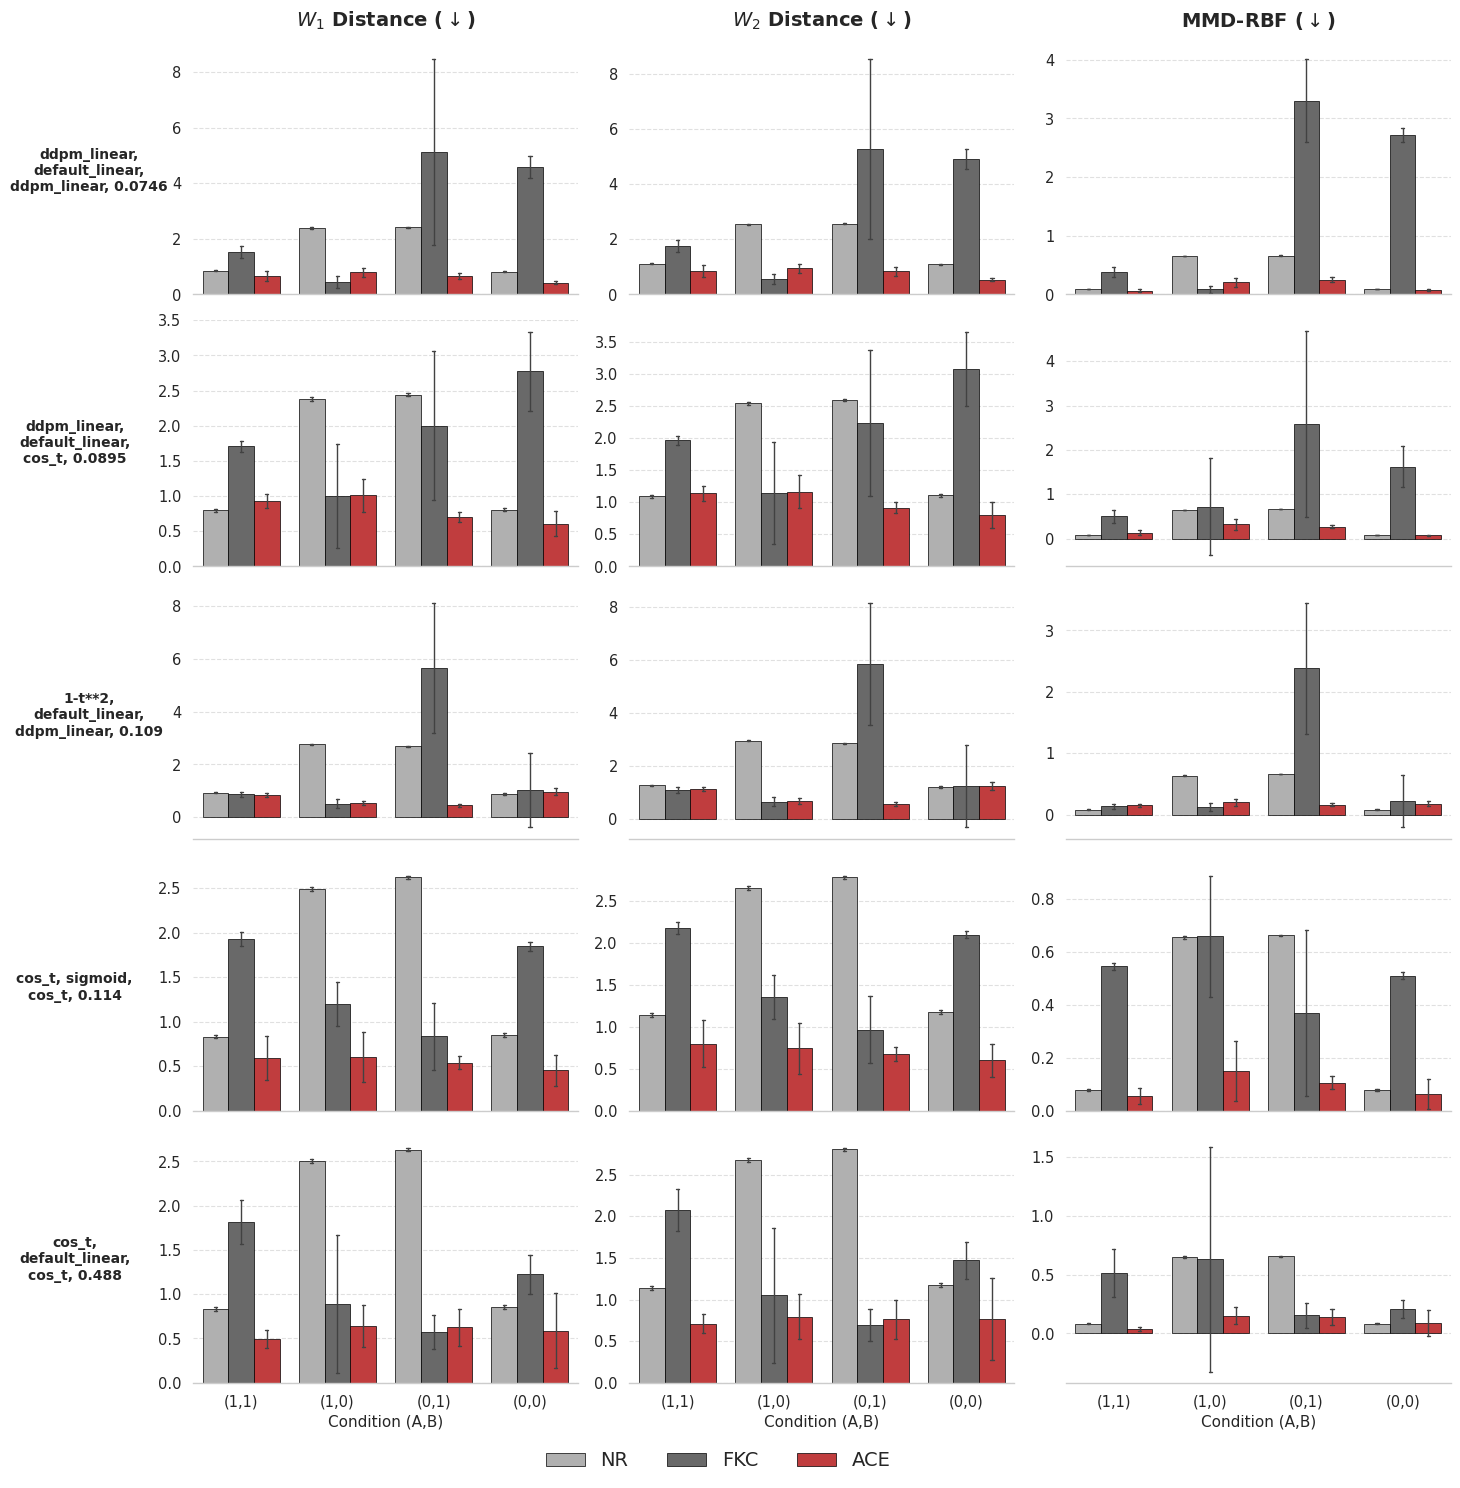

In [13]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# ==========================================
# CONFIGURATION
# ==========================================
PARENT_DIR = "[251117] Rebuttal Figures"
OUTPUT_FILENAME = "Rebuttal_Facet_Grid_Swapped.png"

# Metrics to plot (Columns)
METRICS = ['W1', 'W2', 'MMD_RBF']
METRIC_LABELS = {
    'W1': r'$W_1$ Distance ($\downarrow$)',
    'W2': r'$W_2$ Distance ($\downarrow$)',
    'MMD_RBF': r'MMD-RBF ($\downarrow$)'
}

# Methods and Colors (Highlight ACE)
PALETTE = {
    'NR': '#B0B0B0',   # Light Gray
    'FKC': '#696969',  # Dark Gray
    'ACE': '#D62728'   # Bold Red
}

# Order of plotting on X-axis
METHOD_ORDER = ['NR', 'FKC', 'ACE']

# ==========================================
# 1. DATA LOADING
# ==========================================
def load_all_data(parent_dir):
    all_data = []
    
    # 1. ROBUST FOLDER FINDING
    try:
        subdirs = [
            os.path.join(parent_dir, d) for d in os.listdir(parent_dir) 
            if os.path.isdir(os.path.join(parent_dir, d)) and d.endswith("_Visualizations")
        ]
    except FileNotFoundError:
        print(f"Error: Parent directory '{parent_dir}' not found.")
        return pd.DataFrame() 
    
    # Sort them based on the float number in the first bracket
    def sort_key(path):
        match = re.search(r"\[([\d\.]+)\]", os.path.basename(path))
        return float(match.group(1)) if match else 0
    
    subdirs.sort(key=sort_key)

    for i, folder_path in enumerate(subdirs):
        folder_name = os.path.basename(folder_path)
        
        # Extract a clean title for the Case
        try:
            case_label = folder_name.split(']')[1].split('_Visualizations')[0]
        except:
            case_label = f"Case {i+1}"

        # 2. ROBUST CSV FINDING
        try:
            files_in_folder = os.listdir(folder_path)
            csv_files = [
                os.path.join(folder_path, f) for f in files_in_folder
                if f.startswith("experiment_results") and f.endswith(".csv")
            ]
        except OSError:
            print(f"Could not access folder: {folder_name}")
            continue

        if not csv_files:
            print(f"Skipping {folder_name}: No results CSV found.")
            continue
            
        # Read Data
        df = pd.read_csv(csv_files[0])
        
        # Create the Condition Column
        df['Condition'] = df.apply(lambda row: f"({int(row['A'])},{int(row['B'])})", axis=1)
        
        # Add Case info
        df['Case'] = case_label
        df['Case_Index'] = i 
        
        all_data.append(df)

    if not all_data:
        raise ValueError("No data found! Check your paths.")
        
    return pd.concat(all_data, ignore_index=True)

# ==========================================
# 2. PLOTTING
# ==========================================
def create_facet_plot(df):
    # Get unique cases in order
    cases = df.sort_values('Case_Index')['Case'].unique()
    
    # Setup Grid: Rows = Cases, Cols = Metrics (SWAPPED)
    n_cases = len(cases)
    n_metrics = len(METRICS)
    
    # Adjusted figsize for Taller layout
    # Width = based on metrics, Height = based on cases
    fig, axes = plt.subplots(n_cases, n_metrics, figsize=(5 * n_metrics, 3.0 * n_cases), sharex=True)
    
    # Global styling
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.2)

    print("Generating Plots...")

    # Loop: Rows (Cases) then Cols (Metrics)
    for row_idx, case in enumerate(cases):
        for col_idx, metric in enumerate(METRICS):
            
            # Handle 1D array of axes if n_metrics=1 or n_cases=1
            if n_cases > 1 and n_metrics > 1:
                ax = axes[row_idx, col_idx]
            elif n_cases > 1:
                ax = axes[row_idx]
            elif n_metrics > 1:
                ax = axes[col_idx]
            else:
                ax = axes

            # Filter data for this specific Case
            subset = df[df['Case'] == case]
            
            # Plot Bar Chart
            sns.barplot(
                data=subset,
                x='Condition',
                y=metric,
                hue='method',
                hue_order=METHOD_ORDER,
                palette=PALETTE,
                ax=ax,
                edgecolor='black',
                linewidth=0.5,
                errorbar='sd',
                capsize=0.1,
                err_kws={'linewidth': 1}
            )
            
            # --- FORMATTING ---

            # 1. Column Headers (Metrics) - Only on Top Row
            if row_idx == 0:
                ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight='bold', pad=15)
            else:
                ax.set_title("")

            # 2. Row Headers (Cases) - Only on Left Column
            # We put the Case Name as the Y-Label, rotated
            if col_idx == 0:
                clean_case = case.replace("'", "").replace("[", "").replace("]", "")
                # Wrap text specifically for the Y-axis label
                wrapped_case = "\n".join(textwrap.wrap(clean_case, width=20))
                ax.set_ylabel(wrapped_case, fontsize=10, fontweight='bold', rotation=0, labelpad=60, va='center')
            else:
                ax.set_ylabel("")

            # 3. X-Axis Labels - Only on Bottom Row
            if row_idx == n_cases - 1:
                ax.set_xlabel("Condition (A,B)", fontsize=11)
            else:
                ax.set_xlabel("")

            # Grid and Spines
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
            sns.despine(ax=ax, left=True)
            
            # Remove individual legends
            if ax.get_legend():
                ax.get_legend().remove()

    # Create a single global legend at the bottom
    # We grab handles from the very first plot
    handles, labels = (axes[0, 0] if n_cases > 1 and n_metrics > 1 else axes[0]).get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='lower center', ncol=3, 
               bbox_to_anchor=(0.5, -0.01), fontsize=14, frameon=False)

    plt.tight_layout()
    
    # Adjust margins (Top for titles, Bottom for legend, Left for Case names)
    plt.subplots_adjust(top=0.95, bottom=0.06, left=0.15)
    
    output_path = os.path.join(PARENT_DIR, OUTPUT_FILENAME)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Success! Plot saved to: {output_path}")
    plt.show()

if __name__ == "__main__":
    if os.path.exists(PARENT_DIR):
        combined_df = load_all_data(PARENT_DIR)
        if not combined_df.empty:
            create_facet_plot(combined_df)
    else:
        print(f"Error: Directory '{PARENT_DIR}' not found.")

Generating Plots...
Success! Plot saved to: [251117] Rebuttal Figures/Rebuttal_Facet_Grid_Swapped.png


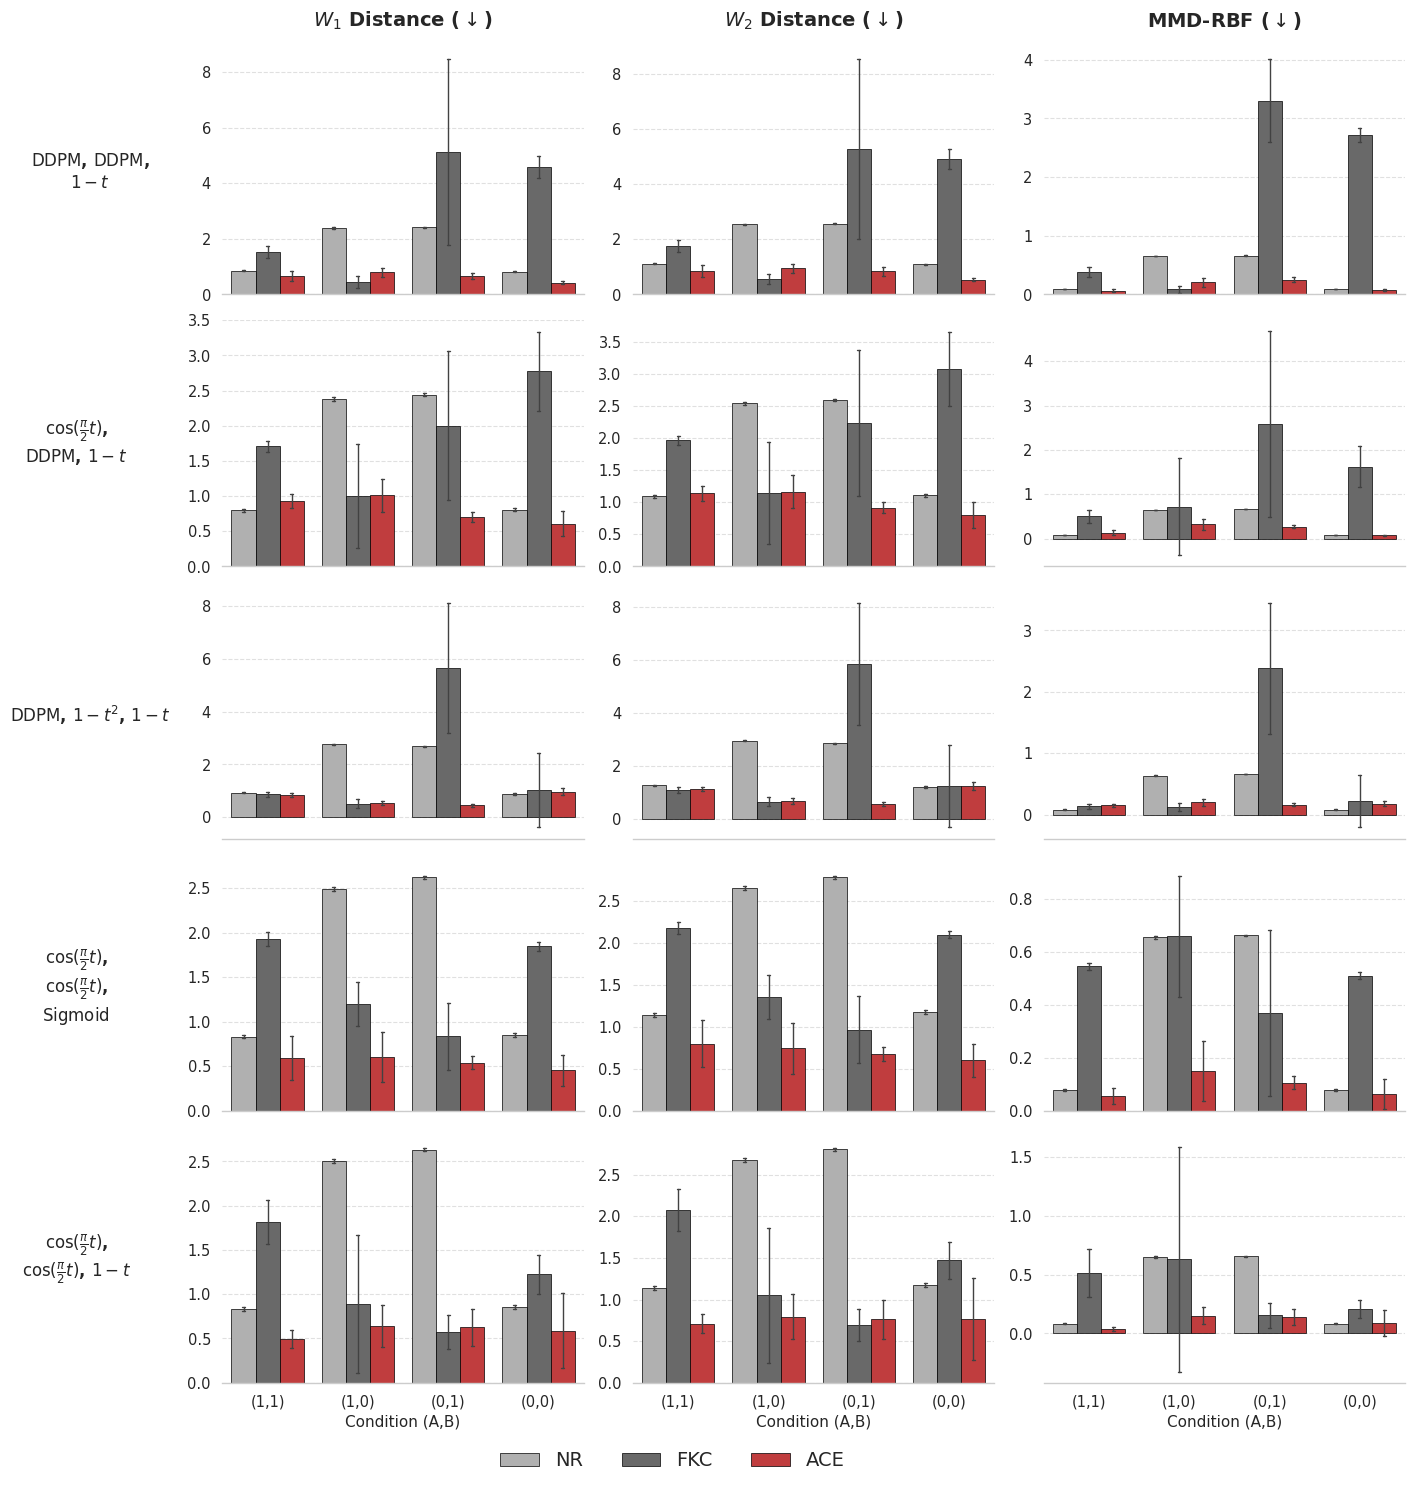

In [15]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
import ast

# ==========================================
# CONFIGURATION
# ==========================================
PARENT_DIR = "[251117] Rebuttal Figures"
OUTPUT_FILENAME = "Rebuttal_Facet_Grid_Swapped.png"

# Metrics to plot (Columns)
METRICS = ['W1', 'W2', 'MMD_RBF']
METRIC_LABELS = {
    'W1': r'$W_1$ Distance ($\downarrow$)',
    'W2': r'$W_2$ Distance ($\downarrow$)',
    'MMD_RBF': r'MMD-RBF ($\downarrow$)'
}

# LaTeX Mappings for Schedules
NAME_EQ_PLOT = {
    "ddpm_linear": r"$\text{DDPM}$",
    "1-t**2": r"$1-t^2$",
    "sigmoid": r"$\text{Sigmoid}$",
    "default_linear": r"$1-t$",
    "cos_t": r"$\cos(\frac{\pi}{2}t)$"
}

# Methods and Colors (Highlight ACE)
PALETTE = {
    'NR': '#B0B0B0',   # Light Gray
    'FKC': '#696969',  # Dark Gray
    'ACE': '#D62728'   # Bold Red
}

# Order of plotting on X-axis
METHOD_ORDER = ['NR', 'FKC', 'ACE']

# ==========================================
# 1. DATA LOADING
# ==========================================
def load_all_data(parent_dir):
    all_data = []
    
    # 1. ROBUST FOLDER FINDING
    try:
        subdirs = [
            os.path.join(parent_dir, d) for d in os.listdir(parent_dir) 
            if os.path.isdir(os.path.join(parent_dir, d)) and d.endswith("_Visualizations")
        ]
    except FileNotFoundError:
        print(f"Error: Parent directory '{parent_dir}' not found.")
        return pd.DataFrame() 
    
    # Sort them based on the float number in the first bracket
    def sort_key(path):
        match = re.search(r"\[([\d\.]+)\]", os.path.basename(path))
        return float(match.group(1)) if match else 0
    
    subdirs.sort(key=sort_key)

    for i, folder_path in enumerate(subdirs):
        folder_name = os.path.basename(folder_path)
        
        # Extract and parse the schedule list for the Case Label
        try:
            # The folder structure is usually: [sort_val]['s1', 's2', 's3', len]_Visualizations
            # We extract the list part between ']' and '_Visualizations'
            # folder_name.split(']')[1] usually gives "['s1', 's2', 's3', len"
            raw_list_part = folder_name.split(']')[1].split('_Visualizations')[0]
            
            # Reconstruct into a valid python list string for parsing
            if not raw_list_part.endswith(']'):
                raw_list_part += ']'
            
            # Parse list
            schedule_list = ast.literal_eval(raw_list_part)
            
            # Take first 3 elements, map to LaTeX
            schedules = schedule_list[:3]
            latex_schedules = [NAME_EQ_PLOT.get(s, s) for s in schedules]
            # move the last element to the front
            latex_schedules = [latex_schedules[2]] + latex_schedules[:2]
            
            # Join with commas
            case_label = ", ".join(latex_schedules)

        except Exception as e:
            print(f"Warning: Could not parse label for {folder_name}, using default. Error: {e}")
            case_label = f"Case {i+1}"

        # 2. ROBUST CSV FINDING
        try:
            files_in_folder = os.listdir(folder_path)
            csv_files = [
                os.path.join(folder_path, f) for f in files_in_folder
                if f.startswith("experiment_results") and f.endswith(".csv")
            ]
        except OSError:
            print(f"Could not access folder: {folder_name}")
            continue

        if not csv_files:
            print(f"Skipping {folder_name}: No results CSV found.")
            continue
            
        # Read Data
        df = pd.read_csv(csv_files[0])
        
        # Create the Condition Column
        df['Condition'] = df.apply(lambda row: f"({int(row['A'])},{int(row['B'])})", axis=1)
        
        # Add Case info
        df['Case'] = case_label
        df['Case_Index'] = i 
        
        all_data.append(df)

    if not all_data:
        raise ValueError("No data found! Check your paths.")
        
    return pd.concat(all_data, ignore_index=True)

# ==========================================
# 2. PLOTTING
# ==========================================
def create_facet_plot(df):
    # Get unique cases in order
    cases = df.sort_values('Case_Index')['Case'].unique()
    
    # Setup Grid: Rows = Cases, Cols = Metrics (SWAPPED)
    n_cases = len(cases)
    n_metrics = len(METRICS)
    
    # Adjusted figsize for Taller layout
    # Width = based on metrics, Height = based on cases
    fig, axes = plt.subplots(n_cases, n_metrics, figsize=(5 * n_metrics, 3.0 * n_cases), sharex=True)
    
    # Global styling
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.2)

    print("Generating Plots...")

    # Loop: Rows (Cases) then Cols (Metrics)
    for row_idx, case in enumerate(cases):
        for col_idx, metric in enumerate(METRICS):
            
            # Handle 1D array of axes if n_metrics=1 or n_cases=1
            if n_cases > 1 and n_metrics > 1:
                ax = axes[row_idx, col_idx]
            elif n_cases > 1:
                ax = axes[row_idx]
            elif n_metrics > 1:
                ax = axes[col_idx]
            else:
                ax = axes

            # Filter data for this specific Case
            subset = df[df['Case'] == case]
            
            # Plot Bar Chart
            sns.barplot(
                data=subset,
                x='Condition',
                y=metric,
                hue='method',
                hue_order=METHOD_ORDER,
                palette=PALETTE,
                ax=ax,
                edgecolor='black',
                linewidth=0.5,
                errorbar='sd',
                capsize=0.1,
                err_kws={'linewidth': 1}
            )
            
            # --- FORMATTING ---

            # 1. Column Headers (Metrics) - Only on Top Row
            if row_idx == 0:
                ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight='bold', pad=15)
            else:
                ax.set_title("")

            # 2. Row Headers (Cases) - Only on Left Column
            # We put the Case Name as the Y-Label, rotated
            if col_idx == 0:
                # No need to replace characters as we already cleaned it in load_all_data
                # Wrap text specifically for the Y-axis label
                # Increased width slightly since latex strings can be long but render short
                wrapped_case = "\n".join(textwrap.wrap(case, width=30))
                ax.set_ylabel(wrapped_case, fontsize=12, fontweight='bold', rotation=0, labelpad=80, va='center')
            else:
                ax.set_ylabel("")

            # 3. X-Axis Labels - Only on Bottom Row
            if row_idx == n_cases - 1:
                ax.set_xlabel("Condition (A,B)", fontsize=11)
            else:
                ax.set_xlabel("")

            # Grid and Spines
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
            sns.despine(ax=ax, left=True)
            
            # Remove individual legends
            if ax.get_legend():
                ax.get_legend().remove()

    # Create a single global legend at the bottom
    # We grab handles from the very first plot
    handles, labels = (axes[0, 0] if n_cases > 1 and n_metrics > 1 else axes[0]).get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='lower center', ncol=3, 
               bbox_to_anchor=(0.5, -0.01), fontsize=14, frameon=False)

    plt.tight_layout()
    
    # Adjust margins (Top for titles, Bottom for legend, Left for Case names)
    # Increased left margin for the longer LaTeX labels
    plt.subplots_adjust(top=0.95, bottom=0.06, left=0.2)
    
    output_path = os.path.join(PARENT_DIR, OUTPUT_FILENAME)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Success! Plot saved to: {output_path}")
    plt.show()

if __name__ == "__main__":
    if os.path.exists(PARENT_DIR):
        combined_df = load_all_data(PARENT_DIR)
        if not combined_df.empty:
            create_facet_plot(combined_df)
    else:
        print(f"Error: Directory '{PARENT_DIR}' not found.")

Generating Plots...
Success! Plot saved to: [251117] Rebuttal Figures/Rebuttal_Facet_Grid_Final.png


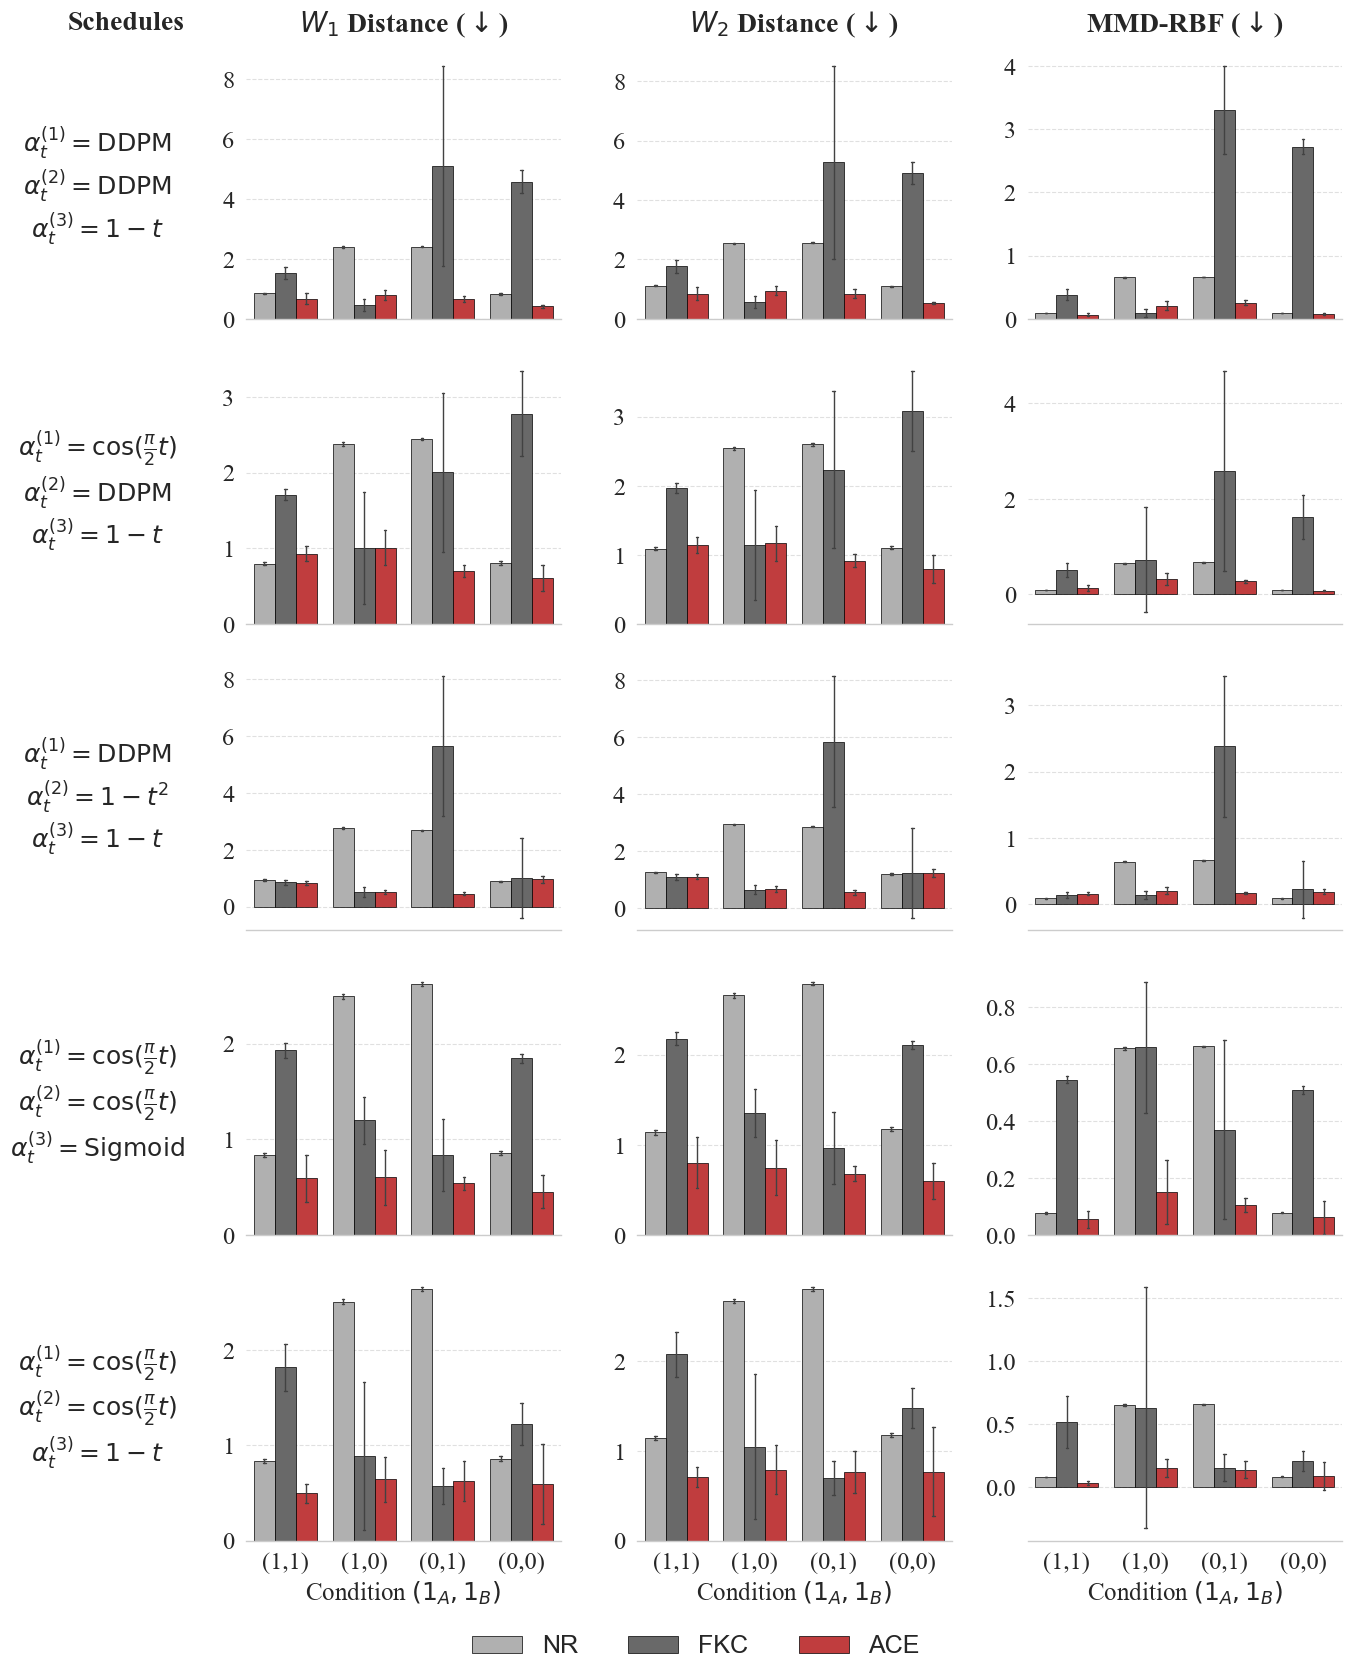

In [14]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# ==========================================
# CONFIGURATION
# ==========================================
PARENT_DIR = "[251117] Rebuttal Figures"
OUTPUT_FILENAME = "Rebuttal_Facet_Grid_Final.png"
plt.rcParams['savefig.dpi'] = 300 # For saved figure resolution

# Metrics to plot (Columns)
METRICS = ['W1', 'W2', 'MMD_RBF']
METRIC_LABELS = {
    'W1': r'$W_1$ Distance ($\downarrow$)',
    'W2': r'$W_2$ Distance ($\downarrow$)',
    'MMD_RBF': r'MMD-RBF ($\downarrow$)'
}

# LaTeX Mappings for Schedules
NAME_EQ_PLOT = {
    "ddpm_linear": r"$\text{DDPM}$",
    "1-t**2": r"$1-t^2$",
    "sigmoid": r"$\text{Sigmoid}$",
    "default_linear": r"$1-t$",
    "cos_t": r"$\cos(\frac{\pi}{2}t)$"
}

# Methods and Colors (Highlight ACE)
PALETTE = {
    'NR': '#B0B0B0',   # Light Gray
    'FKC': '#696969',  # Dark Gray
    'ACE': '#D62728'   # Bold Red
}

# Order of plotting on X-axis
METHOD_ORDER = ['NR', 'FKC', 'ACE']

# ==========================================
# 1. DATA LOADING
# ==========================================
def load_all_data(parent_dir):
    all_data = []
    
    # 1. ROBUST FOLDER FINDING
    try:
        subdirs = [
            os.path.join(parent_dir, d) for d in os.listdir(parent_dir) 
            if os.path.isdir(os.path.join(parent_dir, d)) and d.endswith("_Visualizations")
        ]
    except FileNotFoundError:
        print(f"Error: Parent directory '{parent_dir}' not found.")
        return pd.DataFrame() 
    
    # Sort them based on the float number in the first bracket
    def sort_key(path):
        match = re.search(r"\[([\d\.]+)\]", os.path.basename(path))
        return float(match.group(1)) if match else 0
    
    subdirs.sort(key=sort_key)

    for i, folder_path in enumerate(subdirs):
        folder_name = os.path.basename(folder_path)
        
        # Extract and parse the schedule list for the Case Label
        try:
            # The folder structure is usually: [sort_val]['s1', 's2', 's3', len]_Visualizations
            # We extract the list part between ']' and '_Visualizations'
            raw_list_part = folder_name.split(']')[1].split('_Visualizations')[0]
            
            if not raw_list_part.endswith(']'):
                raw_list_part += ']'
            
            # Parse list
            schedule_list = ast.literal_eval(raw_list_part)
            schedules = schedule_list[:3]
            
            # 1. Map to LaTeX (strip existing $ so we can wrap it uniformly)
            latex_schedules = [NAME_EQ_PLOT.get(s, s).replace('$', '') for s in schedules]
            
            # 2. Apply Reordering Logic (User specified: [2, 0, 1])
            # Original: [s1, s2, s3] -> New: [s3, s1, s2]
            reordered = [latex_schedules[2]] + latex_schedules[:2]
            
            # 3. Format into 3 lines: alpha^(i)_t = val
            formatted_lines = []
            for idx, val in enumerate(reordered):
                # Construct LaTeX string: $\alpha^{(i)}_t = val$
                # Using raw strings to handle backslashes safely
                line = r"$\alpha^{(" + str(idx+1) + r")}_t = " + val + r"$"
                formatted_lines.append(line)
            
            case_label = "\n".join(formatted_lines)

        except Exception as e:
            print(f"Warning: Could not parse label for {folder_name}, using default. Error: {e}")
            case_label = f"Case {i+1}"

        # 2. ROBUST CSV FINDING
        try:
            files_in_folder = os.listdir(folder_path)
            csv_files = [
                os.path.join(folder_path, f) for f in files_in_folder
                if f.startswith("experiment_results") and f.endswith(".csv")
            ]
        except OSError:
            print(f"Could not access folder: {folder_name}")
            continue

        if not csv_files:
            print(f"Skipping {folder_name}: No results CSV found.")
            continue
            
        # Read Data
        df = pd.read_csv(csv_files[0])
        df['Condition'] = df.apply(lambda row: f"({int(row['A'])},{int(row['B'])})", axis=1)
        df['Case'] = case_label
        df['Case_Index'] = i 
        all_data.append(df)

    if not all_data:
        raise ValueError("No data found! Check your paths.")
        
    return pd.concat(all_data, ignore_index=True)

# ==========================================
# 2. PLOTTING
# ==========================================
def create_facet_plot(df):
    # --- FONT SETTINGS ---
    # Set global font family to serif
    plt.rcParams['font.family'] = 'Times New Roman'
    sns.set_context("paper", font_scale=2)

    cases = df.sort_values('Case_Index')['Case'].unique()
    n_cases = len(cases)
    n_metrics = len(METRICS)
    
    # Increase height per case to accommodate 3 lines of text
    # Width = 5 * n_metrics, Height = 3.5 * n_cases (was 3.0)
    fig, axes = plt.subplots(n_cases, n_metrics, figsize=(5 * n_metrics, 3.5 * n_cases), sharex=True)
    
    sns.set_style("whitegrid")

    print("Generating Plots...")

    for row_idx, case in enumerate(cases):
        for col_idx, metric in enumerate(METRICS):
            
            if n_cases > 1 and n_metrics > 1:
                ax = axes[row_idx, col_idx]
            elif n_cases > 1:
                ax = axes[row_idx]
            elif n_metrics > 1:
                ax = axes[col_idx]
            else:
                ax = axes

            subset = df[df['Case'] == case]
            
            sns.barplot(
                data=subset,
                x='Condition',
                y=metric,
                hue='method',
                hue_order=METHOD_ORDER,
                palette=PALETTE,
                ax=ax,
                edgecolor='black',
                linewidth=0.5,
                errorbar='sd',
                capsize=0.1,
                err_kws={'linewidth': 1}
            )
            
            # Headers
            if row_idx == 0:
                ax.set_title(METRIC_LABELS[metric], fontsize=20, fontweight='bold', pad=15)
            else:
                ax.set_title("")

            # Row Labels (Case Names)
            if col_idx == 0:
                # No textwrap! The string already has newlines.
                # Using va='center' to align the 3 lines block with the plot center
                # labelpad moves it left.
                ax.set_ylabel(case, fontsize=18, rotation=0, labelpad=90, va='center')
            else:
                ax.set_ylabel("")

            if row_idx == n_cases - 1:
                ax.set_xlabel(r"Condition $(1_A,1_B)$", fontsize=18)
            else:
                ax.set_xlabel("")

            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
            sns.despine(ax=ax, left=True)
            
            if ax.get_legend():
                ax.get_legend().remove()

    # Global Legend
    handles, labels = (axes[0, 0] if n_cases > 1 and n_metrics > 1 else axes[0]).get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, 
               bbox_to_anchor=(0.55, -0.01), fontsize=18, frameon=False)

    plt.tight_layout()
    
    # Adjust Margins
    # Increased left margin (0.2 -> 0.25) for the wider 3-line labels
    plt.subplots_adjust(top=0.92, bottom=0.07, left=0.25)
    
    # Add "Schedules" Header
    # Placed in the top-left margin area
    # x=0.125 is roughly centered in the 0.25 left margin
    fig.text(0.17, 0.93, "Schedules", fontsize=20, fontweight='bold', ha='center', va='bottom', fontfamily='Times New Roman')
    
    output_path = os.path.join(PARENT_DIR, OUTPUT_FILENAME)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Success! Plot saved to: {output_path}")
    plt.show()

if __name__ == "__main__":
    if os.path.exists(PARENT_DIR):
        combined_df = load_all_data(PARENT_DIR)
        if not combined_df.empty:
            create_facet_plot(combined_df)
    else:
        print(f"Error: Directory '{PARENT_DIR}' not found.")